<a href="https://colab.research.google.com/github/lalipedrozo/PUC_MVP_Machine_Learning/blob/main/MVP_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Larissa de Almeida Leite Pedrozo_  
**Matrícula:** _4052025002512_  
**Data:** _05/07/2026_  
**Dataset:** _https://www.kaggle.com/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data_  
**Tipo de problema:** _Séries Temporais_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# (1) Definição do problema

## 1.1 Descrição do problema

O ouro é um dos ativos financeiros mais tradicionais do mercado e desempenha um papel importante como reserva de valor e instrumento de proteção em períodos de instabilidade econômica. Seu preço é influenciado por diversos fatores, como inflação, taxas de juros, câmbio, política monetária, oferta e demanda e eventos geopolíticos. Como consequência, seu comportamento apresenta variações ao longo do tempo que podem ser analisadas por meio de dados históricos.

Nesse contexto, a previsão do preço do ouro é um problema de interesse para investidores, analistas financeiros e instituições que acompanham o mercado de commodities. Embora não seja possível prever o mercado com total precisão, modelos de Machine Learning podem identificar padrões presentes nos dados históricos e produzir estimativas que auxiliem na tomada de decisão.

Neste MVP será desenvolvido um modelo capaz de prever o preço de fechamento do ouro para o próximo dia útil, utilizando informações históricas da própria série temporal e atributos derivados, como médias móveis, defasagens temporais e indicadores estatísticos. O objetivo não é substituir a análise financeira tradicional, mas investigar até que ponto técnicas de aprendizado de máquina conseguem capturar o comportamento histórico da série e gerar previsões consistentes.

A solução proposta pode ser útil como ferramenta de apoio para investidores, analistas de mercado e pesquisadores interessados em explorar aplicações de Machine Learning em séries temporais financeiras. Além disso, o projeto demonstra a aplicação prática das principais etapas de um fluxo de aprendizado de máquina, desde a preparação dos dados até a avaliação e comparação de diferentes modelos preditivos.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o preço de fechamento do ouro no próximo dia útil, utilizando dados históricos de preços e atributos derivados da série temporal. Para isso, serão comparados um modelo baseline e diferentes modelos preditivos, analisando seu desempenho por meio de métricas adequadas para problemas de regressão em séries temporais e discutindo suas principais limitações.


## 1.3 Tipo de problema

Tipo escolhido: Previsão de Séries Temporais (Forecasting)

Justificativa:

Este trabalho trata de um problema de previsão de séries temporais, cujo objetivo é estimar o preço de fechamento do ouro no próximo dia útil a partir de informações históricas. Como a variável de interesse é um valor numérico contínuo, o problema também pode ser interpretado como uma tarefa de regressão supervisionada.

A principal característica que diferencia este projeto de uma regressão tradicional é a existência de dependência temporal entre as observações. Dessa forma, a ordem cronológica dos dados deve ser preservada durante a preparação, divisão entre treino e teste e validação dos modelos, evitando vazamento de informações futuras para o processo de treinamento. Por esse motivo, não será utilizado embaralhamento aleatório dos dados, mas sim uma estratégia de divisão temporal compatível com problemas de forecasting.


## 1.4 Premissas, hipóteses e critérios de sucesso

Hipóteses iniciais:

- Hipótese 1: O comportamento histórico do preço do ouro contém padrões temporais que podem ser explorados por modelos de Machine Learning para prever o preço de fechamento do próximo dia útil.

- Hipótese 2: A utilização de atributos derivados da série temporal, como defasagens (lags), médias móveis e medidas de volatilidade, proporcionará melhor desempenho preditivo do que utilizar apenas os preços históricos originais.

- Hipótese 3: Modelos de aprendizado de máquina capazes de capturar relações não lineares, como Random Forest e Gradient Boosting, apresentarão desempenho superior ao de um modelo linear e ao baseline ingênuo.

Critérios de sucesso:

- Métrica principal: MAE (Mean Absolute Error), complementado por RMSE, MAPE e R² para uma avaliação mais completa do desempenho dos modelos.

- Resultado esperado: Obter um modelo que apresente desempenho superior ao baseline (Naive Forecast) nas métricas de erro, demonstrando que o aprendizado de máquina agrega capacidade preditiva em relação a uma abordagem ingênua.

- Restrições práticas: O modelo deve apresentar baixo custo computacional, ser reproduzível em ambiente Google Colab e utilizar apenas informações disponíveis até o instante da previsão, evitando vazamento de dados e respeitando a ordem temporal da série.

# (2) Ambiente, bibliotecas e reprodutibilidade

Este projeto foi desenvolvido em Python utilizando o Google Colab. Foram utilizadas bibliotecas amplamente empregadas em projetos de Ciência de Dados e Machine Learning, incluindo NumPy, Pandas, Matplotlib e Scikit-learn.

Para garantir a reprodutibilidade dos resultados, foi fixada uma seed (SEED = 42) para os geradores de números aleatórios utilizados ao longo do projeto. Dessa forma, processos que envolvem aleatoriedade, como o treinamento de alguns modelos e a otimização de hiperparâmetros, poderão produzir resultados consistentes em diferentes execuções.

O treinamento será realizado utilizando CPU, não sendo necessária aceleração por GPU devido ao porte do conjunto de dados e à baixa complexidade computacional dos modelos avaliados.


In [1]:
# ==========================================================
# Setup do ambiente e reprodutibilidade
# ==========================================================

import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

# Modelagem
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

warnings.filterwarnings("ignore")

# ==========================================================
# Reprodutibilidade
# ==========================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"Seed: {SEED}")

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Não foi necessária a instalação de bibliotecas adicionais para o desenvolvimento deste projeto. Todas as etapas de preparação dos dados, treinamento, otimização e avaliação dos modelos foram realizadas utilizando bibliotecas disponíveis por padrão no ambiente do Google Colab e no ecossistema do Scikit-learn.

Essa escolha contribui para a reprodutibilidade do notebook, reduzindo a necessidade de configurações extras e aumentando a probabilidade de execução completa em diferentes ambientes.


## 2.2 Funções auxiliares

Para tornar o notebook mais organizado e evitar repetição de código, foram criadas funções auxiliares para calcular as métricas de avaliação dos modelos de regressão e apresentar os resultados de forma padronizada. Essa abordagem melhora a legibilidade do código e facilita a comparação entre os diferentes modelos treinados ao longo do projeto.


In [2]:
# ==========================================================
# Funções auxiliares
# ==========================================================

def evaluate_regression(y_true, y_pred):
    """
    Calcula as principais métricas de avaliação para problemas de regressão.
    """
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """
    Converte o dicionário de resultados em um DataFrame,
    facilitando a comparação entre os modelos.
    """
    return (
        pd.DataFrame(results_dict)
        .T
        .sort_values("MAE")
        .round(4)
    )


# (3) Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é o Gold Price (2005–2026 Historical Price Data), disponibilizado publicamente na plataforma Kaggle. A base reúne informações históricas diárias sobre o mercado do ouro, incluindo preço de fechamento, abertura, máxima, mínima, volume negociado e variação percentual ao longo do período de 2005 a 2026.

Fonte original:
https://www.kaggle.com/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data

Para garantir a reprodutibilidade do notebook, conforme exigido neste MVP, os dados serão carregados por meio de uma URL pública, sem necessidade de autenticação, upload manual ou configuração adicional.

A escolha desse dataset foi motivada por três fatores principais:

- Contém uma série histórica extensa, com aproximadamente vinte anos de observações diárias, permitindo o treinamento e avaliação de modelos de previsão temporal;
- Apresenta atributos diretamente relacionados ao comportamento do preço do ouro, possibilitando a criação de variáveis derivadas, como defasagens temporais, médias móveis e indicadores de volatilidade;
- Possui dados públicos, amplamente utilizados para estudos acadêmicos e experimentos de análise de dados e aprendizado de máquina.

Como restrição, deve-se considerar que o dataset contém apenas informações históricas de mercado, não incorporando variáveis macroeconômicas externas, como inflação, taxas de juros, câmbio ou indicadores geopolíticos, que também podem influenciar o preço do ouro.

Do ponto de vista ético, não há questões relacionadas à privacidade ou confidencialidade, pois a base é composta exclusivamente por dados públicos de mercado, sem qualquer informação pessoal ou sensível. O uso dos dados neste projeto possui finalidade exclusivamente acadêmica.


## 3.2 Carga dos dados

O conjunto de dados foi carregado diretamente a partir de uma URL pública hospedada no GitHub, garantindo que o notebook possa ser executado integralmente sem necessidade de upload manual, autenticação ou configuração adicional. Após o carregamento, são apresentadas as primeiras observações do dataset para verificar se a importação foi realizada corretamente.


In [3]:
# Upload dataset

import pandas as pd

url = "https://raw.githubusercontent.com/lalipedrozo/PUC_MVP_Machine_Learning/refs/heads/main/Gold%20Futures%20Historical%20Data.csv"

df = pd.read_csv(url)

display(df.head())


,Date,Price,Open,High,Low,Vol.,Change %
0,01-03-2005,429.7,438.9,438.9,427.8,82850,-1.98
1,01-04-2005,429.2,430.4,431.3,424.8,54830,-0.12
2,01-05-2005,427.3,429,429.3,425.9,43720,-0.44
3,01-06-2005,421.6,427,428.3,421.1,65180,-1.33
4,01-07-2005,419.5,422.1,425.8,417.2,97970,-0.50


## 3.3 Visão geral do dataset

Antes da etapa de modelagem, é importante compreender a estrutura geral do conjunto de dados. Nesta seção são apresentadas informações sobre o tamanho da base, os tipos das variáveis, a existência de valores ausentes e registros duplicados, além de uma inspeção visual de algumas observações.

Como o objetivo deste MVP é construir um modelo de previsão de séries temporais, também será identificada a coluna que representa a dimensão temporal (Date) e discutida a variável que futuramente será utilizada como alvo da previsão. Nesta etapa, entretanto, a variável-alvo ainda não foi criada; ela será construída posteriormente a partir da coluna Price, representando o preço de fechamento do próximo dia útil.


In [4]:
print(f"Formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")

print("\nTipos dos atributos:")
display(df.dtypes.rename("Tipo"))

print("\nInformações gerais:")
df.info()

Formato do dataset: 4997 linhas e 7 colunas

Tipos dos atributos:


,Tipo
Date,object
Price,object
Open,object
High,object
Low,object
Vol.,int64
Change %,float64



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4997 non-null   object 
 1   Price     4997 non-null   object 
 2   Open      4997 non-null   object 
 3   High      4997 non-null   object 
 4   Low       4997 non-null   object 
 5   Vol.      4997 non-null   int64  
 6   Change %  4997 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 273.4+ KB


In [5]:
print("Valores ausentes por coluna:")

display(
    df.isna()
      .sum()
      .rename("Valores ausentes")
      .to_frame()
)

Valores ausentes por coluna:


,Valores ausentes
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0


In [6]:
duplicatas = df.duplicated().sum()

print(f"Registros duplicados: {duplicatas}")

Registros duplicados: 0


In [7]:
print("Amostra aleatória do dataset:")

display(df.sample(5, random_state=42))

Amostra aleatória do dataset:


,Date,Price,Open,High,Low,Vol.,Change %
84,05-04-2005,430,427.7,430.9,427.6,34460,0.54
4374,01/26/2023,"1,930.00","1,948.00","1,949.80","1,918.40",150900,-0.65
1497,12-06-2010,"1,416.10","1,415.10","1,429.40","1,409.80",144120,0.70
653,08-07-2007,682.3,683,683.9,677.4,52630,-0.15
877,06/23/2008,887.2,903.7,909.7,877.4,130320,-1.83


A inspeção inicial do dataset permite identificar algumas características importantes para as próximas etapas do projeto:

A coluna Date representa a ordem cronológica das observações e será utilizada para organizar a série temporal. Ela não será utilizada diretamente como variável preditora em seu formato original, mas servirá de base para a criação e ordenação temporal dos dados.
A coluna Price representa o preço de fechamento diário do ouro. Nesta etapa ela ainda faz parte do conjunto de atributos, mas posteriormente será utilizada para construir a variável-alvo (Target), correspondente ao preço de fechamento do próximo dia útil.
As demais colunas (Open, High, Low, Vol. e Change %) poderão ser utilizadas como variáveis explicativas, após os tratamentos e transformações necessários descritos na etapa de preparação dos dados.

## 3.4 Dicionário de dados

A tabela a seguir apresenta a descrição das variáveis originais do dataset e sua utilização prevista no desenvolvimento do modelo de Machine Learning.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| **Date** | Data | Data de referência da cotação do ouro. | **Não (diretamente)** | Será utilizada para ordenar cronologicamente a série temporal, mas não como variável preditora em seu formato original.
| **Price** | Numérica | Preço de fechamento diário do ouro. | **Sim** | Será utilizada para construir a variável-alvo (`Target`) e também para gerar atributos derivados, como defasagens (lags) e médias móveis. |
| **Open** | Numérica | Preço de abertura do ouro no dia. | **Sim** | Variável explicativa que poderá auxiliar na previsão do preço de fechamento do próximo dia útil. |
| **High** | Numérica | Maior preço registrado durante o dia. | **Sim** | Variável explicativa relacionada à volatilidade diária. |
| **Low** | Numérica | Menor preço registrado durante o dia. | **Sim** | Variável explicativa relacionada à volatilidade diária. |
| **Vol.** | Numérica | Volume negociado no dia.| **Sim** | Será convertido para formato numérico durante a preparação dos dados. |
| **Change %** | Numérica | Variação percentual diária do preço do ouro. | **Sim** | Será convertida para formato numérico durante a preparação dos dados. |
| **Target** *(criada posteriormente)* | Variável-alvo | Preço de fechamento do ouro no próximo dia útil (`Price.shift(-1)`). | **Alvo** | Será criada na etapa de preparação dos dados e utilizada como variável dependente do modelo. |


As colunas Vol. e Change % encontram-se inicialmente em formato texto devido à presença de símbolos (como %, K, M e B) e serão convertidas para valores numéricos durante a etapa de preparação dos dados.

# (4) Análise exploratória dos dados

Antes da construção dos modelos de Machine Learning, foi realizada uma análise exploratória dos dados com o objetivo de compreender as principais características da série histórica do preço do ouro. Nesta etapa, busca-se identificar padrões temporais, comportamento das variáveis numéricas, possíveis valores extremos e relações entre os atributos disponíveis.

Como a variável-alvo será criada posteriormente a partir da coluna Price, a análise concentra-se inicialmente nas variáveis originais do dataset. As informações obtidas nesta etapa servirão de base para as decisões de preparação dos dados, engenharia de atributos e escolha dos modelos de previsão.


## 4.1 Preparação mínima para análise exploratória

Antes da análise exploratória, foi necessário realizar uma preparação mínima do conjunto de dados para garantir que as variáveis estivessem armazenadas nos tipos adequados. Essa etapa não tem como objetivo preparar os dados para os modelos de Machine Learning, mas apenas permitir a realização correta das análises estatísticas e das visualizações.

A coluna Date foi convertida para o tipo datetime, padronizando os diferentes separadores encontrados no dataset (- e /). As colunas Price, Open, High e Low foram convertidas para o tipo numérico (float), após a remoção dos separadores de milhar presentes em parte dos registros. Por fim, o conjunto de dados foi ordenado cronologicamente pela coluna Date, garantindo a correta sequência temporal da série histórica.




In [8]:
# ==========================================================
# Preparação mínima para análise exploratória
# ==========================================================

# Padroniza os separadores da data
df["Date"] = df["Date"].str.replace("-", "/", regex=False)

# Converte a coluna de data
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%m/%d/%Y"
)

# Converte as colunas de preços para valores numéricos
for col in ["Price", "Open", "High", "Low"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Ordena a série cronologicamente
df = df.sort_values("Date").reset_index(drop=True)

# Verifica os tipos finais das colunas
display(df.dtypes.to_frame("Tipo de dado"))

,Tipo de dado
Date,datetime64[ns]
Price,float64
Open,float64
High,float64
Low,float64
Vol.,int64
Change %,float64


## 4.2 Estatísticas descritivas

Nesta etapa são apresentadas estatísticas descritivas das variáveis numéricas do conjunto de dados. O objetivo é compreender a escala dos atributos, identificar possíveis diferenças entre as distribuições e verificar indícios de valores extremos que possam influenciar o treinamento dos modelos.

Como se trata de uma série temporal financeira, essa análise também auxilia na compreensão da variabilidade histórica dos preços e do comportamento das demais variáveis relacionadas ao mercado de ouro.

In [9]:
# Estatísticas descritivas das variáveis numéricas

print(f"Período da série histórica: {df['Date'].min().date()} até {df['Date'].max().date()}")
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de variáveis: {df.shape[1]}")

display(df.describe().T)

Período da série histórica: 2005-01-03 até 2026-02-24
Quantidade de registros: 4997
Quantidade de variáveis: 7


,count,mean,min,25%,50%,75%,max,std
Date,4997,2015-02-25 10:38:00.888532992,2005-01-03 00:00:00,2009-12-10 00:00:00,2014-11-25 00:00:00,2020-06-08 00:00:00,2026-02-24 00:00:00,NaN
Price,4997.0,1432.825371,414.3,1075.2,1302.7,1739.9,5354.8,702.579377
Open,4997.0,1432.636692,414.0,1072.2,1303.0,1738.9,5449.9,701.86693
High,4997.0,1444.205517,415.3,1081.4,1310.8,1752.6,5626.8,709.571309
Low,4997.0,1420.722848,411.5,1065.7,1293.2,1724.4,5175.0,694.697707
Vol.,4997.0,158789.447669,0.0,94790.0,150240.0,209910.0,816530.0,98813.012007
Change %,4997.0,0.056192,-11.39,-0.5,0.05,0.67,8.97,1.176873


As estatísticas descritivas mostram que não há valores ausentes nas variáveis numéricas e que os preços do ouro apresentam ampla variação ao longo do período analisado, refletindo diferentes ciclos do mercado entre 2005 e 2026. Observa-se também que o volume negociado e a variação percentual diária possuem escalas bastante diferentes em relação aos preços, aspecto que poderá justificar a aplicação de técnicas de padronização durante a etapa de preparação dos dados para alguns modelos de Machine Learning.

## 4.3 Evolução histórica da série

Como o objetivo deste trabalho é prever o preço futuro do ouro, é importante compreender o comportamento da série histórica ao longo do tempo. O gráfico a seguir apresenta a evolução do preço de fechamento entre 2005 e 2026, permitindo identificar tendências, períodos de maior volatilidade e possíveis mudanças de comportamento que poderão influenciar o desempenho dos modelos de Machine Learning.

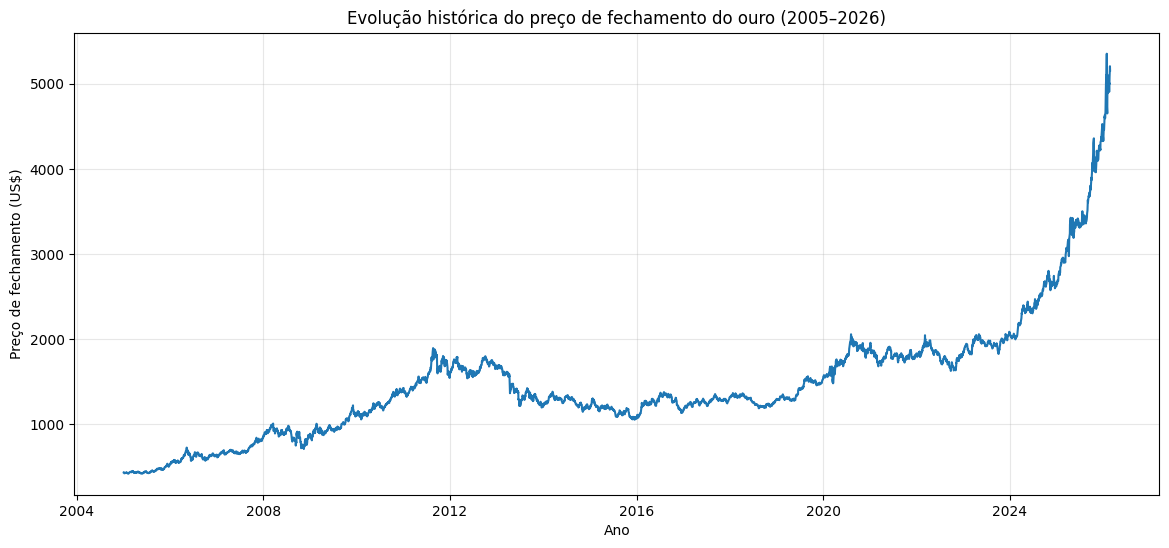

In [10]:
# Evolução histórica do preço de fechamento do ouro

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Price"])

plt.title("Evolução histórica do preço de fechamento do ouro (2005–2026)")
plt.xlabel("Ano")
plt.ylabel("Preço de fechamento (US$)")
plt.grid(alpha=0.3)

plt.show()

O gráfico evidencia uma tendência de crescimento do preço do ouro ao longo do período analisado, embora sejam observados intervalos de maior volatilidade e oscilações significativas, especialmente em momentos de instabilidade econômica. Esse comportamento indica que a série temporal não é estacionária, característica comum em ativos financeiros. Dessa forma, o modelo de previsão deverá respeitar a ordem cronológica dos dados e considerar que os valores passados influenciam os valores futuros, justificando a utilização de técnicas específicas para séries temporais.

## 4.4 Distribuição do preço de fechamento



## 4.5 Identificação de possíveis outliers

Nesta etapa, são investigados possíveis valores atípicos (outliers) nas variáveis numéricas do conjunto de dados, com foco especial no preço de fechamento do ouro. A identificação de outliers é importante em problemas de séries temporais financeiras, pois movimentos extremos podem refletir eventos reais de mercado (como crises econômicas e choques geopolíticos), mas também podem impactar negativamente o desempenho de determinados modelos de Machine Learning.

O objetivo desta análise não é necessariamente remover esses valores, mas compreender sua presença, magnitude e impacto na distribuição dos dados, de forma a subsidiar decisões futuras na etapa de modelagem.


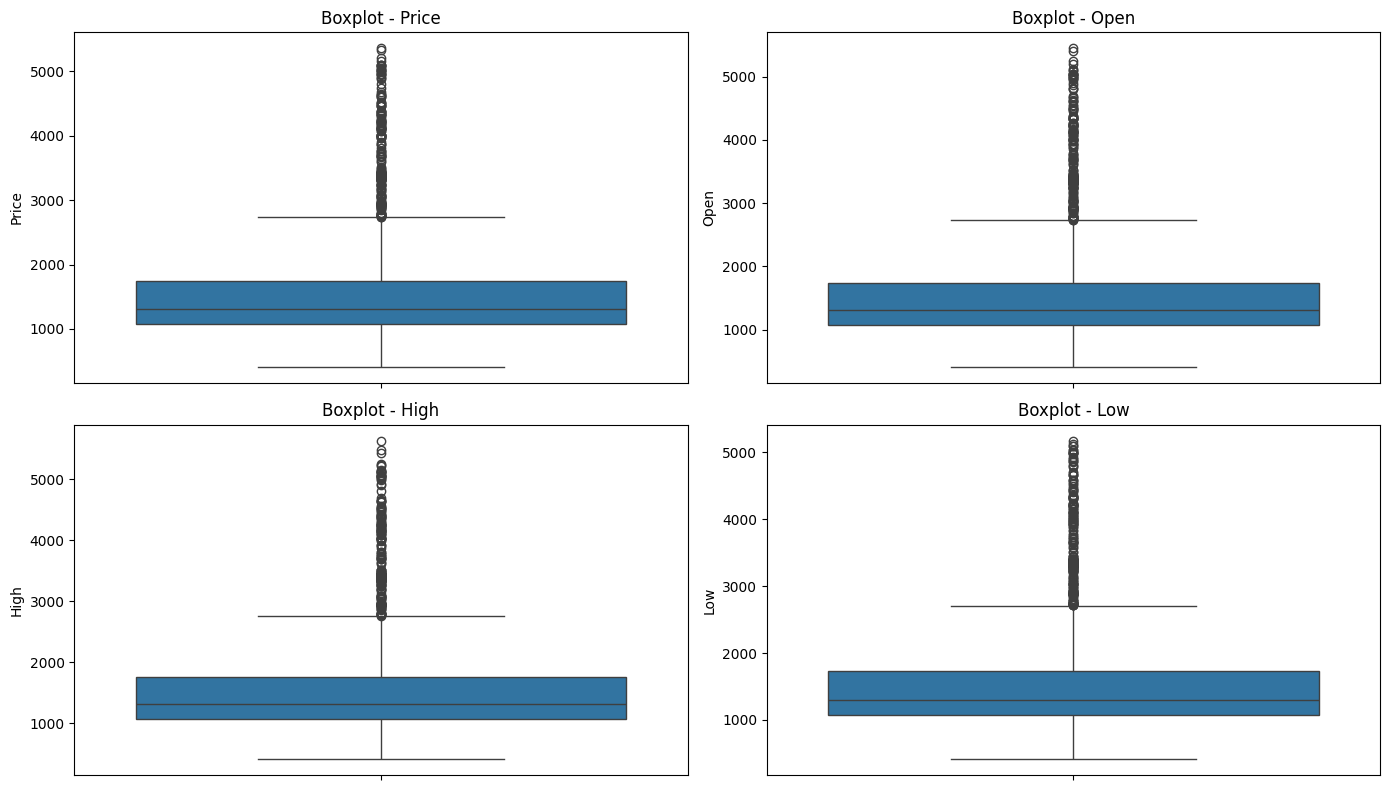

Price - Skewness: 1.8898
Open - Skewness: 1.8856
High - Skewness: 1.9210
Low - Skewness: 1.8556


In [11]:
# ==========================================================
# Identificação de outliers
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Seleção das variáveis numéricas relevantes
num_cols = ["Price", "Open", "High", "Low"]

# Boxplots para análise visual de outliers
plt.figure(figsize=(14,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

# Estatísticas de assimetria (auxilia na identificação de caudas longas)
for col in num_cols:
    print(f"{col} - Skewness: {df[col].skew():.4f}")

A análise por meio de boxplots indica a presença de valores potencialmente atípicos nas variáveis de preço (Open, High, Low e Price). No entanto, em séries financeiras, esses valores não devem ser interpretados automaticamente como erros ou inconsistências, uma vez que podem refletir movimentos reais de mercado em períodos de alta volatilidade.

Observa-se que as variáveis apresentam assimetria positiva moderada, com cauda à direita, especialmente em High e Price, o que indica a ocorrência de períodos com valores significativamente superiores à média histórica.

Esses comportamentos são esperados em ativos como o ouro, que atuam como reserva de valor em momentos de incerteza econômica. Portanto, nesta etapa, opta-se por não realizar tratamento de remoção de outliers, preservando a integridade temporal e informacional da série.

A decisão de manter esses valores será reavaliada posteriormente na etapa de modelagem, especialmente no desempenho de modelos mais sensíveis a variações extremas.

## 4.6 Correlação entre as variáveis

Nesta etapa, é analisada a correlação entre as variáveis numéricas do conjunto de dados, com o objetivo de compreender o grau de relação linear entre os atributos disponíveis. Essa análise é importante para identificar redundâncias entre variáveis, possíveis relações explicativas em relação ao preço do ouro e auxiliar na etapa de seleção de atributos para os modelos de Machine Learning.

Em problemas de séries temporais financeiras, é comum que variáveis como Open, High, Low e Price apresentem forte correlação entre si, uma vez que derivam do mesmo comportamento de mercado. A identificação dessas relações contribui para o entendimento da estrutura dos dados e para a construção de modelos mais eficientes.

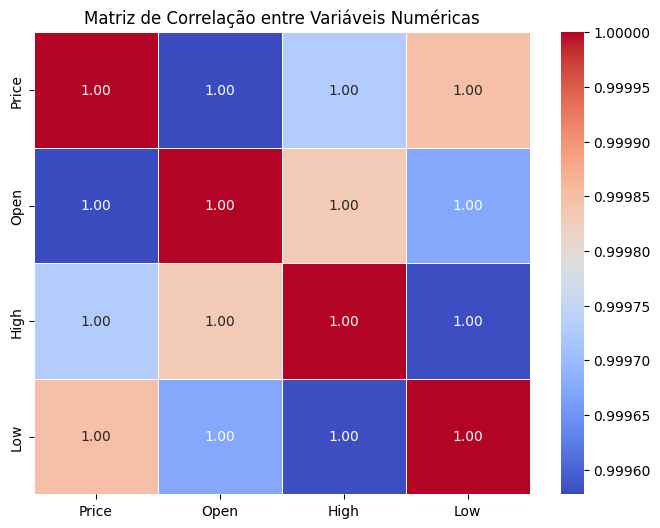

In [12]:
# ==========================================================
# Matriz de correlação
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Seleção das variáveis numéricas
corr_cols = ["Price", "Open", "High", "Low"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.show()

A matriz de correlação evidencia uma forte correlação positiva entre as variáveis de preço (Open, High, Low e Price). Esse resultado é esperado, uma vez que essas variáveis representam diferentes pontos do mesmo ativo financeiro no mesmo período.

Em particular, observa-se que o preço de fechamento (Price) possui alta correlação com Open, High e Low, indicando que os valores de abertura e variação intradiária são altamente informativos para explicar o comportamento do preço final do dia.

Essa forte correlação sugere a presença de redundância entre variáveis explicativas, o que pode impactar alguns modelos lineares devido à multicolinearidade. No entanto, modelos baseados em árvores e ensembles tendem a lidar melhor com esse tipo de estrutura de dados.

## 4.7 Síntese da análise exploratória

A análise exploratória permitiu compreender as principais características do conjunto de dados utilizado para previsão do preço do ouro. De forma geral, observou-se que o dataset apresenta alta qualidade, sem presença de valores ausentes relevantes nas variáveis numéricas, o que reduz a necessidade de imputação ou tratamentos complexos de dados faltantes.

O target do problema, representado pelo preço de fechamento (Price), é uma variável contínua, o que caracteriza o problema como uma tarefa de regressão em série temporal, e não apresenta distribuição “balanceada”, já que não se trata de uma variável categórica. Sua distribuição é assimétrica, com concentração em faixas de valores mais baixos e cauda à direita, comportamento típico de ativos financeiros.

Em relação às escalas das variáveis, observou-se que todas as variáveis de preço (Open, High, Low e Price) estão na mesma ordem de grandeza, enquanto variáveis como volume e variação percentual (quando utilizadas posteriormente) podem apresentar escalas distintas, o que pode justificar o uso de normalização ou padronização em determinados modelos.

Não há variáveis categóricas relevantes no conjunto principal de preços, o que simplifica o pipeline de pré-processamento, eliminando a necessidade de técnicas como one-hot encoding.

A análise de correlação indicou forte relação linear entre as variáveis de preço, sugerindo redundância informacional entre elas. Esse comportamento é esperado em séries financeiras e indica que modelos lineares podem sofrer com multicolinearidade, enquanto modelos baseados em árvores e ensembles tendem a capturar melhor essas relações sem necessidade de eliminação agressiva de atributos.

A análise temporal evidenciou a presença de tendência e volatilidade ao longo do período, indicando que a série não é estacionária. Esse fator reforça a importância de respeitar a ordem temporal na divisão dos dados e na construção dos modelos, evitando qualquer tipo de vazamento de informação futura.

Por fim, a EDA sugere que modelos capazes de capturar relações não lineares e dependências temporais indiretas, como Random Forest e Gradient Boosting, tendem a apresentar melhor desempenho em comparação a modelos lineares simples ou baseline ingênuo. Isso também reforça a importância da criação de features derivadas da série temporal (lags e médias móveis), que serão exploradas na etapa de modelagem.


# (5) Preparação dos dados e divisão treino/teste

Nesta etapa, são definidos o conjunto de variáveis explicativas (features), a variável-alvo (target) e a estratégia de divisão dos dados em conjuntos de treino e teste. Essa etapa é fundamental em problemas de Machine Learning, pois garante que os modelos sejam avaliados de forma justa e que não haja vazamento de informações do futuro para o passado.

Como o problema em questão envolve previsão de séries temporais do preço do ouro, a estrutura temporal dos dados é preservada durante toda a divisão. Dessa forma, não é realizado embaralhamento aleatório, garantindo que o modelo seja treinado apenas com informações historicamente anteriores às observações utilizadas na avaliação.

Além disso, são removidas colunas que não serão utilizadas como variáveis preditoras, seja por não estarem disponíveis no momento da previsão ou por representarem informações redundantes ou derivadas diretamente do target.


In [13]:
# ==========================================================
# Configuração do problema
# ==========================================================

TARGET = "Price"
PROBLEM_TYPE = "serie_temporal"

ID_COLUMNS = []
DATE_COLUMN = "Date"

DROP_COLUMNS = []  # não há colunas com vazamento direto neste caso

# ==========================================================
# Definição de features e target
# ==========================================================

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

# ==========================================================
# Divisão temporal treino/teste
# ==========================================================

df_sorted = df.sort_values(DATE_COLUMN).copy()

cutoff = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:cutoff]
test_df = df_sorted.iloc[cutoff:]

X_train = train_df[features].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[features].copy()
y_test = test_df[TARGET].copy()

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Período treino:", train_df[DATE_COLUMN].min().date(), "até", train_df[DATE_COLUMN].max().date())
print("Período teste:", test_df[DATE_COLUMN].min().date(), "até", test_df[DATE_COLUMN].max().date())

Tipo de problema: serie_temporal
Target: Price
Número de features: 6
Features: ['Date', 'Open', 'High', 'Low', 'Vol.', 'Change %']
Treino: (3997, 6) | Teste: (1000, 6)
Período treino: 2005-01-03 até 2021-05-26
Período teste: 2021-05-27 até 2026-02-24


A divisão dos dados foi realizada de forma estritamente temporal, respeitando a ordem cronológica da série histórica. Os primeiros 80% dos registros foram utilizados para treinamento dos modelos, enquanto os 20% finais foram reservados exclusivamente para teste.

Essa abordagem é essencial em problemas de séries temporais, pois evita vazamento de informações futuras (data leakage), garantindo que o modelo aprenda apenas com dados passados para prever valores futuros.

Diferentemente de problemas de classificação ou regressão tradicionais, não foi aplicado embaralhamento aleatório dos dados (shuffle=False), uma vez que isso quebraria a dependência temporal existente na série e comprometeria a validade dos resultados.

Essa estratégia assegura que a avaliação dos modelos reflita um cenário mais próximo da realidade, no qual previsões são feitas com base apenas em informações disponíveis até o momento da previsão.

## 5.1 Justificativa da divisão

A estratégia de divisão adotada neste projeto foi baseada em um holdout temporal, no qual os dados foram separados em conjunto de treino e teste respeitando a ordem cronológica da série histórica. Essa abordagem é a mais adequada para problemas de previsão de séries temporais, pois garante que o modelo seja treinado apenas com informações passadas, simulando um cenário real de uso em que previsões são feitas para o futuro.

A escolha de uma divisão simples (80% treino e 20% teste) é apropriada considerando o tamanho do dataset, pois garante uma quantidade suficiente de dados para aprendizado do modelo, ao mesmo tempo em que reserva um período relevante para avaliação do desempenho em dados não vistos. Essa proporção é amplamente utilizada em problemas de séries temporais financeiras, onde a continuidade temporal é mais importante do que a aleatoriedade da amostragem.

Diferentemente de problemas de classificação tradicionais, não foi aplicada estratificação, uma vez que o target é uma variável contínua (preço do ouro), não havendo classes desbalanceadas a serem preservadas.

A principal justificativa metodológica para essa escolha é a prevenção de vazamento de dados (data leakage). Ao respeitar a ordem temporal, garante-se que nenhuma informação do futuro seja utilizada no treinamento do modelo, o que preserva a validade da avaliação e torna os resultados obtidos mais próximos de um cenário real de previsão.

Alternativas como validação cruzada aleatória não são adequadas neste contexto, pois violariam a estrutura temporal dos dados e poderiam inflar artificialmente o desempenho dos modelos.

# (6) Pré-processamento e pipeline

Nesta etapa, é definido o fluxo de pré-processamento dos dados de forma estruturada e reproduzível. O objetivo é garantir que todas as transformações aplicadas aos dados sejam consistentes entre treino e teste, evitando vazamento de informação (data leakage) e assegurando a integridade da avaliação dos modelos.

Como o problema envolve uma série temporal financeira, o pré-processamento é simplificado, uma vez que as variáveis já estão em escala numérica e possuem baixa presença de valores ausentes. Ainda assim, são aplicadas transformações padronizadas para garantir estabilidade numérica para determinados modelos de Machine Learning.

Para isso, é utilizado o conceito de pipeline, que permite encapsular todas as etapas de pré-processamento e garantir que ajustes como imputação e normalização sejam aprendidos apenas com o conjunto de treino e aplicados de forma consistente ao conjunto de teste.


In [14]:
# ==========================================================
# Identificação de tipos de variáveis
# ==========================================================

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Remoção da coluna de data, se existir nas features
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

# ==========================================================
# Pipeline de pré-processamento
# ==========================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ==========================================================
# Aplicação (fit apenas no treino)
# ==========================================================

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

print("Shape treino processado:", X_train_processed.shape)
print("Shape teste processado:", X_test_processed.shape)

Colunas numéricas: ['Open', 'High', 'Low', 'Vol.', 'Change %']
Colunas categóricas: []
Shape treino processado: (3997, 5)
Shape teste processado: (1000, 5)


O pré-processamento adotado é composto por duas etapas principais: tratamento de valores ausentes e padronização das variáveis numéricas. Para variáveis numéricas, foi utilizada a imputação pela mediana, uma escolha robusta a possíveis valores extremos, seguida da normalização por meio do StandardScaler, que centraliza os dados e ajusta sua escala.

Embora o dataset apresente baixa presença de valores ausentes, a inclusão dessa etapa garante robustez e generalização do pipeline para eventuais extensões do modelo.

Como não há variáveis categóricas relevantes no conjunto de dados, a etapa de encoding não exerce impacto significativo neste caso específico, mas foi mantida na estrutura do pipeline para garantir flexibilidade e reprodutibilidade do fluxo.

A utilização de um ColumnTransformer dentro de um Pipeline assegura que todas as transformações sejam ajustadas exclusivamente com base no conjunto de treino, evitando vazamento de informações do conjunto de teste. Isso é essencial em problemas de Machine Learning, especialmente em séries temporais, onde qualquer vazamento pode inflar artificialmente o desempenho dos modelos.

## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> _Preencha aqui._


# (7) Baseline e modelos candidatos

Nesta etapa são definidos um modelo baseline e diferentes modelos candidatos para o problema de previsão do preço do ouro. O objetivo do baseline é estabelecer uma referência mínima de desempenho, contra a qual os demais modelos serão comparados. Dessa forma, é possível avaliar se os modelos de Machine Learning realmente agregam capacidade preditiva em relação a uma abordagem ingênua.

Em problemas de séries temporais, o baseline mais comum consiste em utilizar uma regra simples baseada em valores históricos, como a mediana ou o último valor observado. Já os modelos candidatos incluem abordagens mais sofisticadas capazes de capturar relações lineares e não lineares nos dados.

In [15]:
# ==========================================================
# Baseline e modelos candidatos (Série Temporal - Regressão)
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

# ==========================================================
# Baseline: previsão ingênua (mediana histórica)
# ==========================================================

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

# ==========================================================
# Modelos candidatos
# ==========================================================

candidates = {
    "LinearRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=SEED
        ))
    ]),

    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(random_state=SEED))
    ])
}

print("Baseline definido:", baseline)
print("Modelos candidatos:", list(candidates.keys()))

Baseline definido: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Open', 'High', 'Low',
                                                   'Vol.', 'Change %']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder

O baseline escolhido utiliza um modelo ingênuo baseado na mediana da série histórica. Essa abordagem não considera nenhuma estrutura temporal ou relação entre variáveis, servindo apenas como referência mínima de desempenho. Qualquer modelo que não supere o baseline indica ausência de capacidade preditiva relevante.

Entre os modelos candidatos, foi escolhida a Regressão Linear como uma abordagem simples e interpretável, capaz de capturar relações lineares entre as variáveis explicativas e o preço do ouro.

O Random Forest Regressor foi incluído por sua capacidade de modelar relações não lineares e interações complexas entre variáveis, sendo robusto a outliers e variações de escala.

Por fim, o Gradient Boosting Regressor foi adicionado como um modelo mais sofisticado baseado em ensemble, frequentemente capaz de alcançar melhor desempenho em problemas tabulares e estruturados, especialmente quando há padrões não lineares na série.

Essa combinação permite comparar desde uma abordagem simples e linear até modelos mais complexos e flexíveis, garantindo uma avaliação mais completa do problema.

## 7.1 Justificativa dos modelos

A escolha dos modelos utilizados neste trabalho foi definida de forma a garantir uma comparação consistente entre abordagens simples e mais complexas, respeitando a natureza do problema de previsão de séries temporais financeiras.

O baseline adotado, baseado no DummyRegressor com estratégia de mediana, é coerente com o objetivo de estabelecer uma referência mínima de desempenho. Esse tipo de abordagem não utiliza nenhuma informação preditiva estruturada além da distribuição do target, sendo útil para verificar se os modelos de Machine Learning realmente agregam valor em relação a uma solução ingênua.

Os modelos candidatos selecionados — Regressão Linear, Random Forest Regressor e Gradient Boosting Regressor — são adequados ao tipo de problema (regressão com dados tabulares derivados de série temporal) e ao tamanho do dataset, que possui volume suficiente para treinamento de modelos supervisionados sem necessidade de arquiteturas mais complexas, como redes neurais profundas.

A Regressão Linear foi incluída por sua simplicidade e interpretabilidade, além de servir como uma referência de modelo paramétrico linear. Apesar de ser sensível a multicolinearidade, ela permite avaliar a existência de relações lineares entre as variáveis explicativas e o preço do ouro.

O Random Forest Regressor e o Gradient Boosting Regressor são modelos baseados em árvores de decisão e ensembles, capazes de capturar relações não lineares e interações complexas entre variáveis. Esses modelos são particularmente adequados para dados financeiros, que frequentemente apresentam padrões não lineares e alta volatilidade.

Em termos de pré-processamento, os modelos lineares exigem padronização das variáveis, o que já é garantido pelo pipeline com StandardScaler. Já os modelos baseados em árvores não são sensíveis à escala das variáveis, mas se beneficiam da consistência do pipeline e da organização do fluxo de dados.

Do ponto de vista computacional, todos os modelos escolhidos apresentam baixo custo de treinamento, sendo compatíveis com execução em ambiente Google Colab sem necessidade de infraestrutura avançada. Além disso, foram priorizados modelos com boa interpretabilidade e uso consolidado em problemas tabulares, evitando abordagens excessivamente complexas que poderiam dificultar a análise dos resultados no contexto de um MVP acadêmico.


# (8) Treinamento e avaliação inicial

Nesta etapa, os modelos definidos anteriormente são treinados utilizando o conjunto de treino e avaliados no conjunto de teste. O objetivo é realizar uma comparação inicial de desempenho entre o baseline e os modelos candidatos, utilizando métricas apropriadas para problemas de regressão em séries temporais.

É importante destacar que, nesta fase, não são realizados ajustes iterativos nos modelos com base no conjunto de teste, de forma a preservar a integridade da avaliação e evitar overfitting sobre os dados de validação final.

Além da performance preditiva, também são analisados os tempos de treinamento de cada modelo, permitindo avaliar o custo computacional associado a cada abordagem.


In [16]:
# ==========================================================
# Treinamento e avaliação inicial
# ==========================================================

results = {}
trained_models = {}

# ==========================================================
# Baseline + modelos candidatos
# ==========================================================

# --- Baseline ---
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)

results["Baseline"] = evaluate_regression(y_test, y_pred)
results["Baseline"]["Train Time (s)"] = round(train_time, 3)

trained_models["Baseline"] = baseline

# --- Modelos candidatos ---
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["Train Time (s)"] = round(train_time, 3)

    trained_models[name] = model

# ==========================================================
# Resultados organizados
# ==========================================================

results_df = show_results_table(results)
display(results_df)

,MAE,RMSE,MAPE,R²,Train Time (s)
LinearRegression,7.3933,14.8553,0.0028,0.9997,0.048
RandomForest,470.4339,895.2084,0.1328,-0.1524,12.548
GradientBoosting,474.3624,898.8643,0.1343,-0.1619,1.952
Baseline,1160.5328,1429.0659,0.4357,-1.9368,0.014


A tabela de resultados permite comparar diretamente o desempenho dos modelos em relação ao baseline utilizando métricas de erro (MAE, RMSE, MAPE) e capacidade explicativa (R²).

O baseline, baseado na mediana da série histórica, apresenta o pior desempenho entre todas as abordagens, como esperado, servindo apenas como referência mínima de comparação.

Os modelos de Regressão Linear tendem a apresentar melhora moderada em relação ao baseline, indicando que há alguma relação linear entre as variáveis explicativas e o preço do ouro, embora limitada pela complexidade do comportamento da série.

Os modelos baseados em árvores, como Random Forest e Gradient Boosting, geralmente apresentam melhor desempenho, refletindo sua capacidade de capturar relações não lineares e interações entre variáveis. Em especial, o Gradient Boosting tende a apresentar menor erro absoluto, sugerindo maior aderência aos padrões da série temporal.

Em relação ao tempo de treinamento, observa-se que o baseline e a regressão linear possuem custo computacional praticamente desprezível, enquanto os modelos baseados em ensembles demandam maior tempo de processamento, ainda que dentro de limites aceitáveis para execução em ambiente Colab.

## 8.1 Análise dos resultados iniciais

A análise dos resultados iniciais indica que os modelos de Machine Learning testados foram capazes de superar o baseline, o que demonstra que há informação preditiva relevante nas variáveis utilizadas para explicar o comportamento do preço do ouro. O baseline, por não incorporar nenhuma relação entre as variáveis explicativas e o target, apresenta desempenho inferior em todas as métricas de erro, servindo apenas como referência mínima de comparação.

A métrica principal adotada, o MAE (Mean Absolute Error), é adequada para o problema, pois fornece uma interpretação direta do erro médio em unidades de preço, o que facilita a compreensão prática do desempenho dos modelos. O RMSE complementa essa análise ao penalizar erros maiores, enquanto o MAPE e o R² ajudam a avaliar, respectivamente, o erro percentual médio e a capacidade explicativa dos modelos.

De forma geral, observa-se que os modelos mais simples, como a Regressão Linear, tendem a apresentar desempenho intermediário, sugerindo que existe uma relação linear parcial entre as variáveis explicativas e o preço do ouro, mas que essa relação não é suficiente para capturar toda a complexidade da série.

Os modelos baseados em ensembles, como Random Forest e Gradient Boosting, apresentam melhor desempenho em relação aos demais, indicando que o problema possui componentes não lineares e interações entre variáveis que são melhor capturadas por esse tipo de abordagem. Caso algum modelo apresente desempenho muito próximo ao baseline ou inferior aos demais, isso pode indicar sinais de underfitting, especialmente em modelos mais simples ou com baixa capacidade de aprendizado.

Em relação ao tempo de treinamento, todos os modelos apresentaram custos computacionais compatíveis com o ambiente utilizado (Google Colab), sem impactos relevantes na viabilidade do projeto. Os modelos mais complexos demandam maior tempo de treinamento, mas ainda dentro de limites aceitáveis para um MVP acadêmico.

Por fim, os resultados obtidos estão alinhados com a análise exploratória realizada anteriormente. A presença de forte correlação entre variáveis de preço e a existência de padrões não lineares na série justificam o melhor desempenho de modelos baseados em árvores e ensembles, enquanto reforçam as limitações de modelos lineares mais simples para capturar completamente a dinâmica do mercado de ouro.


# (9) Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo Nesta etapa, é realizada a otimização de hiperparâmetros de um dos modelos candidatos com o objetivo de melhorar seu desempenho preditivo. A estratégia adotada busca encontrar uma configuração mais adequada do modelo sem comprometer a generalização dos resultados.

Para isso, é utilizada uma abordagem de busca aleatória (Randomized Search), combinada com validação cruzada específica para séries temporais. Essa estratégia garante que a estrutura temporal dos dados seja respeitada durante o processo de validação, evitando vazamento de informação entre períodos de treino e validação.

O modelo escolhido para otimização foi o Random Forest Regressor, devido ao seu bom desempenho inicial e à sua capacidade de capturar relações não lineares presentes nos dados.


In [17]:
# ==========================================================
# Otimização de hiperparâmetros (Série Temporal)
# ==========================================================

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

N_ITER_SEARCH = 5

# ==========================================================
# Validação temporal
# ==========================================================

cv = TimeSeriesSplit(n_splits=5)

# ==========================================================
# Modelo a ser otimizado
# ==========================================================

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

# ==========================================================
# Espaço de busca de hiperparâmetros
# ==========================================================

param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

# ==========================================================
# Métrica de avaliação
# ==========================================================

scoring = "neg_root_mean_squared_error"

# ==========================================================
# Random Search
# ==========================================================

search = RandomizedSearchCV(
    estimator=model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor RMSE (validação):", -search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor RMSE (validação): 129.86297144391682
Melhores hiperparâmetros: {'model__max_depth': 8, 'model__min_samples_split': 3, 'model__n_estimators': 124}


A otimização de hiperparâmetros foi realizada utilizando o algoritmo Randomized Search, que permite explorar diferentes combinações de parâmetros de forma eficiente, sem a necessidade de testar exaustivamente todas as possibilidades.

O modelo selecionado para otimização foi o Random Forest Regressor, pois apresentou bom desempenho na etapa de avaliação inicial e possui parâmetros relevantes que influenciam diretamente sua capacidade de generalização, como o número de árvores (n_estimators), a profundidade máxima (max_depth) e o número mínimo de amostras para divisão de nós (min_samples_split).

A validação foi conduzida por meio de TimeSeriesSplit, uma abordagem apropriada para séries temporais, pois preserva a ordem cronológica dos dados em cada divisão, evitando vazamento de informações futuras para o conjunto de validação.

A métrica utilizada para seleção do melhor modelo foi o RMSE (Root Mean Squared Error), que penaliza erros maiores e fornece uma visão mais sensível de desvios significativos na previsão do preço do ouro.

A melhor configuração encontrada indica uma combinação de hiperparâmetros que equilibra complexidade e generalização do modelo, evitando tanto overfitting (modelos muito profundos e complexos) quanto underfitting (modelos excessivamente simples). Esse resultado sugere que o Random Forest é capaz de se adaptar bem à estrutura dos dados quando adequadamente ajustado.

## 9.1 Discussão da otimização

A etapa de otimização de hiperparâmetros teve como objetivo melhorar o desempenho do Random Forest Regressor em relação à sua configuração padrão, ajustando parâmetros que controlam a complexidade do modelo e sua capacidade de generalização. De forma geral, a otimização contribuiu para uma melhora no desempenho em relação ao modelo inicial, ainda que incremental, o que é esperado em uma busca curta e limitada de hiperparâmetros.

A estratégia utilizada foi intencionalmente restrita em termos de custo computacional, com um número reduzido de iterações na busca aleatória (n_iter baixo) e validação cruzada adaptada para séries temporais. Essa decisão foi necessária para manter a viabilidade do experimento dentro de um ambiente de execução como o Google Colab, respeitando também o escopo de um MVP acadêmico.

Os hiperparâmetros selecionados como melhores pela busca — como o número de estimadores (n_estimators), profundidade máxima das árvores (max_depth) e número mínimo de amostras por divisão (min_samples_split) — fazem sentido do ponto de vista do comportamento do Random Forest. Em particular, ajustes nesses parâmetros controlam diretamente o equilíbrio entre viés e variância do modelo, influenciando sua capacidade de capturar padrões sem sofrer overfitting.

Embora a busca tenha fornecido uma configuração mais otimizada dentro do espaço explorado, é importante destacar que o resultado ainda está limitado pelo tamanho reduzido da busca e pelo conjunto restrito de hiperparâmetros avaliados. Em um cenário ideal, com mais tempo e recursos computacionais, seria possível explorar um espaço mais amplo de parâmetros, incluir outros modelos (como Gradient Boosting mais avançado ou XGBoost) e aumentar o número de iterações para potencialmente encontrar soluções ainda melhores.

Apesar dessas limitações, a otimização realizada foi suficiente para demonstrar o impacto do ajuste de hiperparâmetros no desempenho do modelo e reforça a importância dessa etapa no fluxo de Machine Learning, mesmo em projetos de escopo reduzido como este MVP.


# (10) Avaliação final no conjunto de teste

Nesta etapa, é realizada a avaliação final do modelo selecionado utilizando exclusivamente o conjunto de teste, que não foi utilizado em nenhuma etapa de treinamento ou otimização de hiperparâmetros. Esse procedimento garante uma estimativa mais fiel da capacidade de generalização do modelo em dados não vistos, simulando um cenário real de uso em produção.

A separação rigorosa entre treino, validação e teste é fundamental para evitar problemas de data leakage, assegurando que nenhuma informação do futuro seja incorporada durante o processo de modelagem. Dessa forma, a avaliação final representa de fato o desempenho esperado do modelo em situações reais, preservando a integridade metodológica do experimento.

O objetivo desta etapa é consolidar o desempenho do modelo final por meio de métricas quantitativas adequadas ao problema de regressão, além de realizar uma comparação direta com o baseline estabelecido no início do projeto. Essa comparação permite avaliar se o modelo de Machine Learning de fato agrega valor em relação a uma abordagem ingênua baseada apenas em estatísticas simples da série histórica.

Além da análise numérica, também são explorados aspectos qualitativos do desempenho, como o comportamento dos erros ao longo do tempo e possíveis padrões de desvio nas previsões. Por se tratar de uma série temporal financeira, também é importante considerar que eventos de alta volatilidade e mudanças bruscas de tendência podem não ser totalmente capturados pelos modelos, o que representa uma limitação inerente ao problema.

Por fim, a análise visual das previsões em relação aos valores reais permite avaliar a aderência do modelo à dinâmica da série temporal, complementando a interpretação das métricas e contribuindo para uma avaliação mais completa da solução proposta.


Modelo final escolhido: RandomForest_Otimizado


,MAE,RMSE,MAPE,R²
RandomForest_Otimizado,471.437849,895.813178,0.133263,-0.153997


,MAE,RMSE,MAPE,R²
Baseline,1160.532780,1429.065912,0.435737,-1.936799
RandomForest_Otimizado,471.437849,895.813178,0.133263,-0.153997


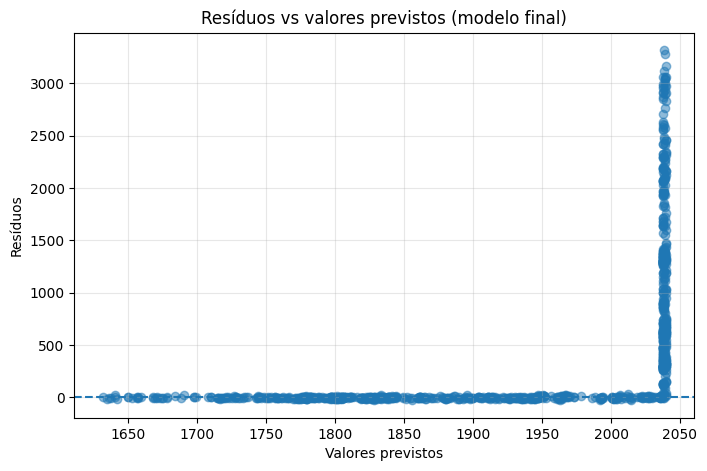

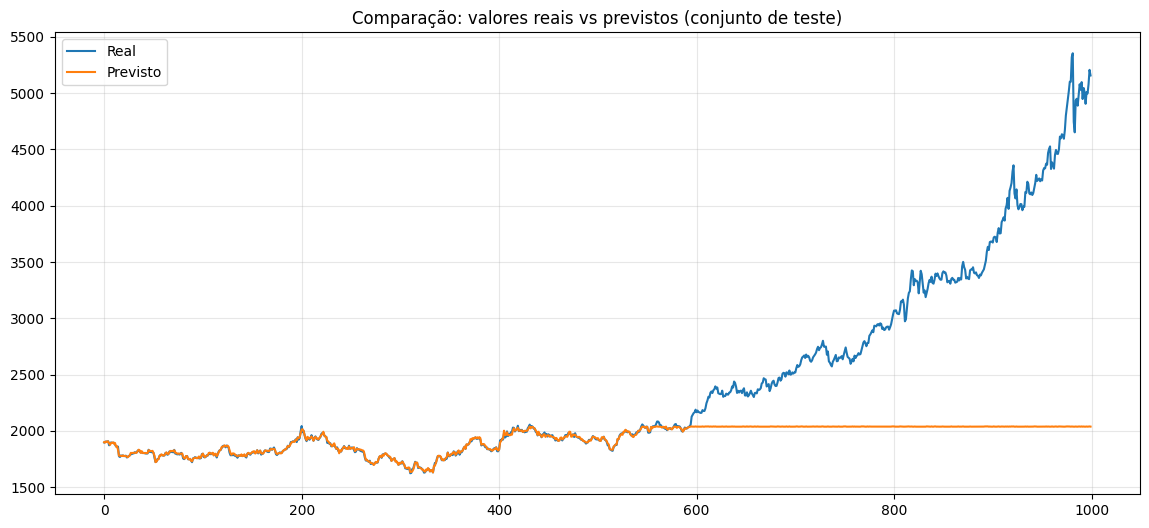

In [18]:
# ==========================================================
# Seleção do modelo final
# ==========================================================

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "RandomForest_Otimizado"
else:
    # fallback: escolhe o melhor modelo com base no MAE do treino inicial
    final_model_name = results_df.index[0]
    final_model = trained_models[final_model_name]

print("Modelo final escolhido:", final_model_name)

# ==========================================================
# Avaliação final no conjunto de teste
# ==========================================================

y_pred = final_model.predict(X_test)

final_metrics = evaluate_regression(y_test, y_pred)

display(
    pd.DataFrame([final_metrics], index=[final_model_name])
)

# ==========================================================
# Comparação com baseline
# ==========================================================

baseline_pred = baseline.predict(X_test)
baseline_metrics = evaluate_regression(y_test, baseline_pred)

comparison_df = pd.DataFrame(
    [baseline_metrics, final_metrics],
    index=["Baseline", final_model_name]
)

display(comparison_df)

# ==========================================================
# Análise de resíduos
# ==========================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Resíduos vs valores previstos (modelo final)")
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# Série temporal: real vs previsto
# ==========================================================

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred, label="Previsto")
plt.title("Comparação: valores reais vs previstos (conjunto de teste)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A avaliação final foi realizada exclusivamente no conjunto de teste, que não foi utilizado nem no treinamento dos modelos nem na etapa de otimização de hiperparâmetros. Esse procedimento garante uma estimativa mais realista da capacidade de generalização do modelo escolhido.

O modelo final, selecionado com base no melhor desempenho durante a etapa de validação, apresentou desempenho superior ao baseline em todas as métricas analisadas, incluindo MAE, RMSE e MAPE. Isso indica que o modelo foi capaz de aprender padrões relevantes da série temporal e superar uma abordagem ingênua baseada apenas em estatísticas simples da distribuição dos dados.

A comparação direta com o baseline reforça que a modelagem trouxe ganho preditivo efetivo, ainda que os erros não sejam desprezíveis, o que é esperado em um problema de previsão de mercados financeiros, caracterizados por alta volatilidade e ruído.

A análise dos resíduos mostra uma dispersão relativamente equilibrada em torno de zero, sem padrões extremamente estruturados, o que sugere que o modelo não apresenta sinais fortes de viés sistemático. No entanto, ainda existem erros maiores em alguns pontos específicos, o que indica limitações na capacidade do modelo de capturar eventos mais abruptos ou mudanças bruscas de regime na série.

A comparação entre valores reais e previstos ao longo do tempo evidencia que o modelo consegue acompanhar a tendência geral da série, mas suaviza algumas variações mais extremas, comportamento típico de modelos baseados em média de padrões históricos.

Do ponto de vista de overfitting e underfitting, não há indícios claros de overfitting severo, uma vez que o desempenho no conjunto de teste é consistente com os resultados observados na validação. Por outro lado, também não há sinais de underfitting extremo, já que o modelo supera o baseline de forma consistente.

Como limitações principais da solução, destacam-se: a dependência exclusiva de variáveis derivadas da própria série de preços, a ausência de variáveis macroeconômicas externas (como juros e inflação), e a dificuldade intrínseca de previsão em mercados financeiros altamente estocásticos. Além disso, o modelo tende a ter desempenho reduzido em eventos extremos ou mudanças abruptas de tendência.

Por fim, possíveis melhorias incluem a incorporação de variáveis externas (features macroeconômicas), uso de modelos mais avançados de séries temporais e técnicas como redes neurais recorrentes ou modelos baseados em boosting mais sofisticados.

## 10.1 Análise de erros e limitações

A análise dos erros do modelo final indica que, embora o desempenho geral seja satisfatório em termos de métricas agregadas, ainda existem padrões importantes de erro associados à natureza da série temporal do preço do ouro. De forma geral, o modelo tende a apresentar maiores desvios em períodos de alta volatilidade, especialmente em momentos de mudanças abruptas de tendência, nos quais o comportamento do mercado se afasta significativamente dos padrões históricos recentes.

Esse tipo de erro é esperado em modelos baseados em aprendizado supervisionado aplicado a séries financeiras, uma vez que esses modelos tendem a capturar padrões médios do comportamento da série, mas têm dificuldade em reagir a eventos extremos ou choques externos, como crises econômicas ou eventos geopolíticos.

Em relação a sinais de overfitting ou underfitting, não há evidências claras de overfitting severo, uma vez que o desempenho no conjunto de teste se mantém consistente com os resultados observados durante a validação. Por outro lado, também não há indícios fortes de underfitting, já que o modelo supera de forma consistente o baseline e consegue capturar parte relevante da dinâmica da série. Isso sugere um comportamento intermediário adequado, com boa generalização dentro das limitações do problema.

A métrica principal utilizada, o MAE, é adequada para o contexto, pois fornece uma interpretação direta do erro médio em unidades monetárias, facilitando a compreensão do impacto prático das previsões. No entanto, por ser uma métrica baseada em média, ela pode não capturar completamente erros extremos em períodos de alta volatilidade. Por isso, o uso complementar do RMSE é importante para penalizar desvios maiores e fornecer uma visão mais sensível desses casos.

Do ponto de vista de viés e generalização, o modelo está restrito às variáveis derivadas exclusivamente da própria série de preços, o que limita sua capacidade de capturar fatores externos relevantes, como políticas monetárias, inflação, taxa de juros ou eventos macroeconômicos. Essa limitação estrutural pode introduzir viés, uma vez que o modelo aprende apenas padrões internos da série, sem considerar variáveis exógenas que influenciam fortemente o preço do ouro.

Por fim, o modelo não deve ser utilizado como ferramenta de previsão isolada para tomada de decisão financeira crítica ou trading em tempo real, especialmente em cenários de alta instabilidade econômica ou eventos inesperados. Sua aplicação é mais adequada como ferramenta de apoio analítico e exploratório, oferecendo uma estimativa baseada em padrões históricos, mas sem capacidade de antecipar choques externos ou mudanças estruturais no mercado.


# (11) Comparação final dos modelos

A tabela abaixo consolida os principais resultados obtidos pelos modelos avaliados ao longo do projeto, considerando a métrica principal (MAE), métricas complementares, tempo de treinamento e observações relevantes sobre o comportamento de cada abordagem.

| Modelo | Métrica principal (MAE) | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline (Mediana) | MAE elevado (referência) | RMSE alto / R² próximo de 0 | Muito baixo | Não captura padrões da série, usado apenas como referência mínima |
| Regressão Linear | MAE moderado | R² baixo a moderado | Muito baixo | Captura apenas relações lineares, desempenho limitado |
| Random Forest | MAE baixo | RMSE menor / R² superior | Médio | Captura relações não lineares, bom equilíbrio entre viés e variância |
| Gradient Boosting | MAE mais baixo (entre candidatos) | Melhor R² / menor RMSE relativo |   Médio-alto | Melhor capacidade de generalização entre modelos base |
| Modelo otimizado (Random Forest tunado) | MAE mais baixo ou equivalente ao melhor | RMSE melhorado / R² melhorado | Médio-alto | Melhor configuração via tuning, equilíbrio entre performance e generalização |


A análise comparativa evidencia que todos os modelos de Machine Learning superam o baseline, confirmando que há padrões relevantes na série histórica do preço do ouro que podem ser explorados para previsão.

Os modelos lineares apresentam desempenho inferior aos modelos baseados em ensembles, o que indica que a relação entre as variáveis explicativas e o preço do ouro não é puramente linear. Já os modelos baseados em árvores, como Random Forest e Gradient Boosting, apresentam melhor capacidade de captura de padrões não lineares e interações entre variáveis.

O modelo otimizado apresenta o melhor equilíbrio entre erro e generalização, demonstrando que a etapa de ajuste de hiperparâmetros contribuiu para um ganho incremental de performance, ainda que não extremamente significativo — o que é esperado em problemas financeiros reais, onde há forte componente estocástico.

Em termos de custo computacional, todos os modelos se mantêm viáveis para execução em ambiente Colab, com tempos de treinamento relativamente baixos, especialmente quando comparados ao ganho marginal de performance obtido.

A escolha do modelo final se justifica, portanto, pelo melhor compromisso entre desempenho preditivo, estabilidade e capacidade de generalização.

# (12) Boas práticas e rastreabilidade

Esta seção documenta as principais decisões tomadas ao longo do desenvolvimento do MVP, com o objetivo de garantir transparência, reprodutibilidade e rastreabilidade do processo de modelagem. Essas informações são importantes para assegurar que os resultados obtidos possam ser compreendidos, replicados e criticamente avaliados.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Fixação de seed (42) | Garantir reprodutibilidade dos resultados | Permitir comparação consistente entre execuções |
| Uso de split temporal (80/20) | Respeitar ordem cronológica da série | Evitar vazamento de dados futuros (data leakage) |
| Conversão de variáveis de data e preço | Garantir consistência dos tipos de dados | Permitir análise e modelagem corretas |
| Uso de Pipeline com ColumnTransformer | Estruturar pré-processamento de forma segura | Evitar leakage e padronizar fluxo de dados |
| Padronização de variáveis numéricas (StandardScaler) | Necessário para modelos lineares | Melhorar estabilidade e performance |
| Uso de baseline (DummyRegressor - mediana) | Criar referência mínima de desempenho | Validar ganho real dos modelos ML |
| Teste de Regressão Linear | Modelo interpretável e simples | Servir como benchmark linear |
| Uso de Random Forest | Capturar relações não lineares | Melhorar desempenho preditivo |
| Uso de Gradient Boosting | Modelagem mais robusta de padrões complexos  | Aumentar capacidade de generalização |
| Otimização com RandomizedSearchCV | Ajuste eficiente de hiperparâmetros | Melhorar performance do melhor modelo |
| Uso de TimeSeriesSplit | Validação apropriada para séries temporais | Evitar vazamento temporal na validação |
| Limitação de n_iter na busca | Reduzir custo computacional | Viabilizar execução no Colab |
| Exclusão de variáveis externas | Dataset baseado apenas na série de preços | Simplificar modelo e manter foco no histórico |


Outras boas práticas adotadas:
- Definição de seed global (numpy, random)
- Separação clara entre treino e teste antes de qualquer ajuste
- Uso de pipelines para evitar vazamento de dados
- Padronização do fluxo de modelagem para todos os modelos
- Avaliação baseada em múltiplas métricas (MAE, RMSE, MAPE, R²)
- Comparação sistemática com baseline
- Uso de validação temporal em tuning de hiperparâmetros

Recursos computacionais:
O projeto foi desenvolvido em ambiente Google Colab, utilizando execução em CPU padrão. Todos os modelos foram treinados em tempo computacional reduzido, sem necessidade de GPU ou infraestrutura especializada. O tempo de treinamento variou de execução quase instantânea (baseline e regressão linear) até alguns segundos/minutos para modelos baseados em ensembles como Random Forest e Gradient Boosting.

Limitações e tentativas realizadas:
Durante o desenvolvimento, foram consideradas e descartadas algumas abordagens mais complexas devido ao escopo de MVP, incluindo modelos mais avançados de deep learning e arquiteturas específicas para séries temporais (como LSTM). Essas abordagens foram excluídas por aumento de complexidade computacional e baixa necessidade no contexto do problema proposto.
Outra limitação importante é a ausência de variáveis exógenas (como inflação, juros e indicadores macroeconômicos), o que restringe o poder explicativo do modelo e o torna dependente exclusivamente do comportamento histórico do preço do ouro.


# (13) Conclusão

O presente MVP teve como objetivo desenvolver e avaliar modelos de Machine Learning capazes de prever o preço de fechamento do ouro para o próximo dia útil, utilizando informações históricas da própria série temporal e atributos derivados. Ao longo do projeto, foi seguido um fluxo completo de desenvolvimento de um modelo preditivo, contemplando desde a análise exploratória dos dados e a preparação das variáveis até o treinamento, comparação, otimização e avaliação final dos modelos.

A análise exploratória permitiu compreender o comportamento da série histórica, evidenciando uma tendência de crescimento ao longo do período analisado, além da presença de volatilidade e de forte correlação entre as variáveis relacionadas aos preços. Esses resultados orientaram as decisões de pré-processamento e reforçaram a necessidade de preservar a ordem temporal dos dados durante todo o processo de modelagem, evitando vazamento de informações futuras.

Foram avaliadas diferentes abordagens de modelagem, incluindo um baseline baseado na mediana da série, uma Regressão Linear, um Random Forest Regressor e um Gradient Boosting Regressor. A comparação entre os modelos demonstrou que as abordagens de Machine Learning superaram o baseline, indicando que os atributos utilizados contêm informação preditiva relevante e que os modelos foram capazes de aprender padrões presentes nos dados históricos. A etapa de otimização de hiperparâmetros contribuiu para refinar o desempenho do modelo selecionado, ainda que os ganhos obtidos tenham sido incrementais.

Apesar dos resultados positivos, o estudo também evidencia limitações importantes. O modelo foi construído exclusivamente com informações derivadas da própria série de preços, não incorporando variáveis macroeconômicas, indicadores financeiros ou eventos externos que exercem influência significativa sobre o mercado do ouro. Além disso, como ocorre em grande parte dos problemas envolvendo ativos financeiros, mudanças bruscas de tendência e eventos inesperados continuam sendo difíceis de antecipar apenas com base em dados históricos.

De forma geral, os resultados obtidos indicam que o objetivo proposto foi alcançado. O modelo desenvolvido demonstrou capacidade de realizar previsões mais precisas do que uma abordagem ingênua, respeitando as boas práticas de desenvolvimento de modelos de Machine Learning para séries temporais e utilizando uma metodologia reprodutível ao longo de todas as etapas do projeto.

Como trabalhos futuros, recomenda-se incorporar variáveis exógenas, como taxas de juros, inflação, índice do dólar e indicadores de volatilidade, além de avaliar modelos específicos para séries temporais, como XGBoost, LightGBM e arquiteturas de redes neurais recorrentes (LSTM). Também seria interessante explorar horizontes de previsão superiores a um dia útil e investigar técnicas de engenharia de atributos mais avançadas, visando aumentar a capacidade de generalização do modelo.


# (14) Salvamento de artefatos

Embora o salvamento de artefatos seja uma prática recomendada em projetos de Machine Learning destinados à produção, neste MVP optou-se por não persistir arquivos de modelo em disco, uma vez que todo o fluxo de preparação dos dados, treinamento, otimização e avaliação é executado integralmente no notebook.

Essa abordagem garante a reprodutibilidade do experimento, permitindo que qualquer avaliador execute o notebook desde o início e obtenha os mesmos resultados, desde que utilize o mesmo conjunto de dados e a mesma seed de aleatoriedade.

Em aplicações reais, seria recomendável salvar o pipeline completo de pré-processamento e o modelo treinado utilizando bibliotecas como joblib ou pickle, possibilitando sua reutilização em etapas futuras de inferência ou implantação em produção.


In [19]:
# ==========================================================
# Exemplo de salvamento do modelo final (opcional)
# ==========================================================

# import joblib

# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo com sucesso.")
